<a href="https://colab.research.google.com/github/negativespace-exe/Econometrics-Work/blob/main/Assignment_5_Econ_6550.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import statsmodels.api as sm

## Using OLS and GLS Linear Regressions to Model Twitch Streamer Data

I used [this dataset](https://www.kaggle.com/datasets/hibrahimag1/top-1000-twitch-streamers-data-may-2024$0) containing data about the top 1000 Twitch streamers to practice calculating and plotting OLS and GLS Linear Regressions.

In [ ]:
# Load the dataset
file_id = "14bSP3KUJ9lCCkhw79cJziPuVC_vulnvS"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
df.head()


,RANK,NAME,LANGUAGE,TYPE,MOST_STREAMED_GAME,2ND_MOST_STREAMED_GAME,AVERAGE_STREAM_DURATION,FOLLOWERS_GAINED_PER_STREAM,AVG_VIEWERS_PER_STREAM,AVG_GAMES_PER_STREAM,TOTAL_TIME_STREAMED,TOTAL_FOLLOWERS,TOTAL_VIEWS,TOTAL_GAMES_STREAMED,ACTIVE_DAYS_PER_WEEK,MOST_ACTIVE_DAY,DAY_WITH_MOST_FOLLOWERS_GAINED
0,1,kaicenat,English,personality,Just Chatting,I'm Only Sleeping,7.6,18405,15852,2.3,4698,10600000,9150000,194,3.6,Friday,Saturday
1,2,jynxzi,English,personality,Tom Clancy's Rainbow Six Siege,NBA 2K20,5.4,3386,1145,1.2,8407,5760000,1950000,54,5.6,Tuesday,Sunday
2,3,caedrel,English,personality,League of Legends,I'm Only Sleeping,6.3,689,12331,1.3,6728,797000,14200000,111,2.8,Thursday,Sunday
3,4,caseoh_,English,personality,NBA 2K23,Just Chatting,4.6,7185,0,3.6,2554,4220000,53,385,6.2,Friday,Monday
4,5,ibai,Spanish,personality,Just Chatting,League of Legends,4.1,8289,190714,1.5,6865,15600000,359000000,149,4.3,Wednesday,Saturday


In [ ]:
df.columns

Index(['RANK', 'NAME', 'LANGUAGE', 'TYPE', 'MOST_STREAMED_GAME',
       '2ND_MOST_STREAMED_GAME', 'AVERAGE_STREAM_DURATION',
       'FOLLOWERS_GAINED_PER_STREAM', 'AVG_VIEWERS_PER_STREAM',
       'AVG_GAMES_PER_STREAM', 'TOTAL_TIME_STREAMED', 'TOTAL_FOLLOWERS',
       'TOTAL_VIEWS', 'TOTAL_GAMES_STREAMED', 'ACTIVE_DAYS_PER_WEEK',
       'MOST_ACTIVE_DAY', 'DAY_WITH_MOST_FOLLOWERS_GAINED'],
      dtype='object')

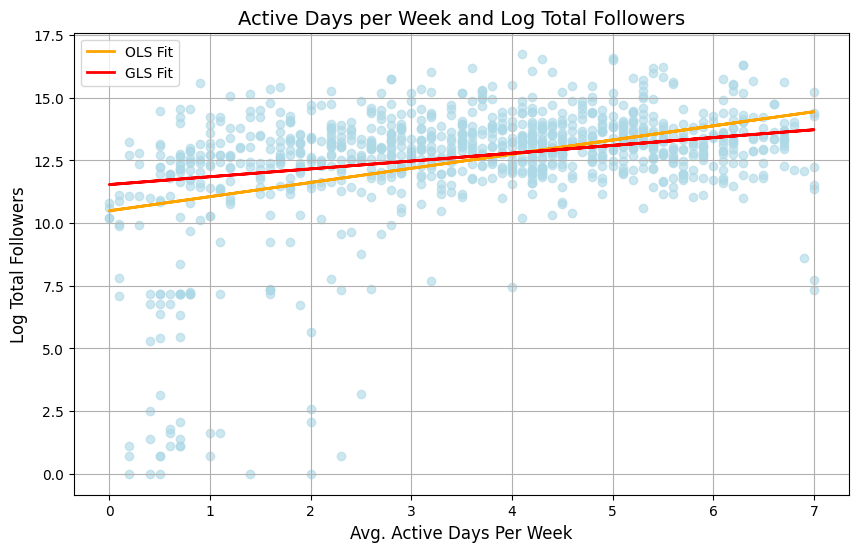

OLS Intercept: 10.491692326615347
OLS Slope: 0.5649234712953124
OLS R²: 0.16912227852571415

GLS Intercept: 11.538911315434595
GLS Slope 0.312411762310703
GLS R² 0.07648851619823238
Omega matrix:
[[0.70336456 0.         0.         ... 0.         0.         0.        ]
 [0.         0.33275081 0.         ... 0.         0.         0.        ]
 [0.         0.         0.94886632 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 2.32958555 0.         0.        ]
 [0.         0.         0.         ... 0.         0.70336456 0.        ]
 [0.         0.         0.         ... 0.         0.         0.25606348]]
Omega inverse:
[[1.42173782 0.         0.         ... 0.         0.         0.        ]
 [0.         3.00525188 0.         ... 0.         0.         0.        ]
 [0.         0.         1.05388924 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.4292609  0.         0.        ]
 [0.         0.         0.         ... 0.       

In [ ]:

# Scatter plot with ACTIVE_DAYS_PER_WEEK on the x-axis and log_followers on the y-axis

df['log_followers'] = np.log1p(df['TOTAL_FOLLOWERS'])
x = df['ACTIVE_DAYS_PER_WEEK'].values.reshape(-1, 1)
y = df['log_followers']


#ols linear regression model
ols_model = linear_model.LinearRegression()
ols_model.fit(x, y)

y_pred = ols_model.predict(x)


#gls linear regression model

#getting residuals from OLS
residuals = y - y_pred

#modeling how variance changes with x (taking log of squared residuals ensures variance will be +)
log_resid_sq = np.log(residuals**2 + 1e-8)

variance_model = linear_model.LinearRegression()
variance_model.fit(x, log_resid_sq)

#estimating variance for each obs
est_var = np.exp(variance_model.predict(x))

#weights (inverse of est_var)
weights = 1 / est_var

#intercept
x_gls = sm.add_constant(x)

#fit WLS
gls_model = sm.WLS(y, x_gls, weights=weights).fit()

y_pred_gls = gls_model.predict(x_gls)

plt.figure(figsize=(10, 6))
plt.scatter(df['ACTIVE_DAYS_PER_WEEK'], df['log_followers'], color='lightblue', alpha=0.6)
plt.plot(x, y_pred, color='orange', linewidth=2, label='OLS Fit')
plt.plot(x, y_pred_gls, color = 'red', linewidth=2, label='GLS Fit')


# Add labels and title
plt.xlabel('Avg. Active Days Per Week', fontsize=12)
plt.ylabel('Log Total Followers', fontsize=12)
plt.title('Active Days per Week and Log Total Followers', fontsize=14)

# Show the plot
plt.legend()
plt.grid(True)
plt.show()

#print statistics
print("OLS Intercept:", ols_model.intercept_)
print("OLS Slope:", ols_model.coef_[0])
print("OLS R²:", ols_model.score(x, y))
print()
print("GLS Intercept:", gls_model.params.iloc[0])
print("GLS Slope", gls_model.params.iloc[1])
print("GLS R²", gls_model.rsquared)

#Omega matrices for GLS
omega = np.diag(est_var)
print("Omega matrix:")
print(omega)

omega_inverse = np.diag(weights)
print("Omega inverse:")
print(omega_inverse)

I plotted the **average number of days** per week the streamers were active against the **log of the total number of followers** that streamer had at the time of data collection. (I chose to plot the log followers to better deal with how the streamers with very high follower counts were making it difficult to see what was happening with the majority of streamers.)

After creating a scatter plot of the data, I noticed that it seemed to exhibit heteroskedasticity, since the variace appeared markedly higher in the number of followers a streamer had when they averaged between 0 and 3 streaming days a week.

After plotting the OLS and a GLS model, you can indeed see the difference in variance between what is happening at between 0 and 3 average streaming days a week and what is happening betwen 4-6 days, which seems to suggest heteroskedasticity. A glance at the omega matrix with its differing values along the diagonal appear to confirm that the data is indeed heteroskedastic.

The OLS and GLS models differ in how they deal with the distribution of the data. The **GLS (WLS) model** overall is less affected by the high variance on the left side of the graph, because its weights are inversely proportional to the variance in X. Greater weight is therefore given to places where the variance is low.

**The OLS model** has a steeper slope because it gives equal weight to all of the data, meaning that we see a lower intercept and a linear model that dips down to account for the data on the left where variance is high.

The omega matrix (and it's inverse) are both diagonal matrices with 0s everywhere but along the diagonals, suggesting that there is no autocorrelation among the errors.

I was interested in visualizing the distribution of the residuals in each model to see if there were any striking differences. Both distributions appear to be relatively normal, which isn't too surprising, but I am interested in what the little bumps on the negative tails at about -5 and -10 might indicate. I'm wondering if this might be a case where there is some factor that is causing a cluster of points to fall at a certain distance from the line, like a specific group of streamers with who all share an important characteristic that is tied to one of these variables. Maybe these are streamers for particular games or for a specific audience? If they represent a specific group, then creating a model to account for all the data might be less helpful than if those groups were identified and modeled separately, or if, at the very least, a categorical variable were introduced to better describe each group.

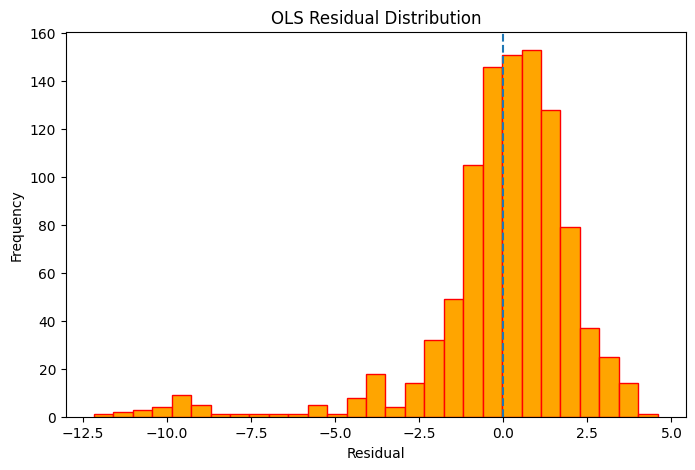

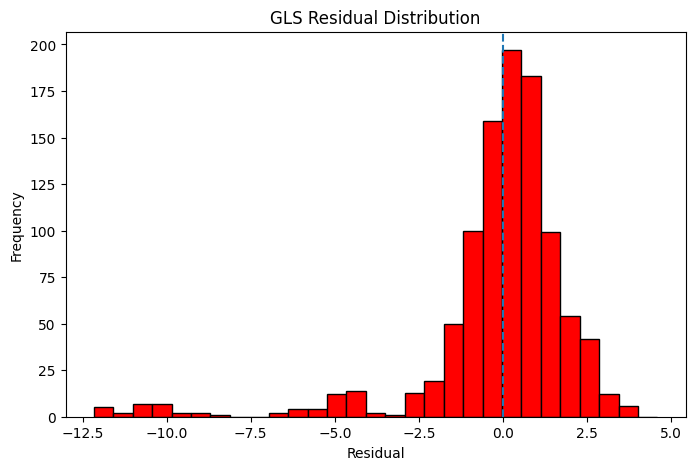

In [ ]:
# Residuals: actual y - predicted y
ols_residuals = y - y_pred
gls_residuals = y - y_pred_gls

# Same bins for both histograms
all_residuals = np.concatenate([ols_residuals, gls_residuals])

bins = np.linspace(
    all_residuals.min(),
    all_residuals.max(),
    30
)

# OLS
plt.figure(figsize=(8, 5))
plt.hist(ols_residuals, bins=bins, color='orange', edgecolor='red')
plt.axvline(0, linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('OLS Residual Distribution')
plt.show()

# GLS
plt.figure(figsize=(8, 5))
plt.hist(gls_residuals, bins=bins, color = 'red', edgecolor='black')
plt.axvline(0, linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('GLS Residual Distribution')
plt.show()

## Heteroskedasticity in Linear Probability Models

LPMs have a binary dependent variable (usually 0 or 1) where the expected value of Y is equal to the probability that Y = 1 (success case):

\begin{equation}
E[Y_i | X_i] = P(Y_i = 1 | X_i)
\end{equation}

where

\begin{equation}
P(Y_i = 1 | X_i) = \beta_0 + \beta_1X_i
\end{equation}

Essentially the line predicts how likely for any given X it is that Y is going to be 1 or 0.

This means that in this kind of linear regression, the residuals are represented by:

\begin{equation}
e_i = 1 - \beta_0 - \beta_1X_i
\end{equation}

in the success case, and

\begin{equation}
e_i = (0)- \beta_0 - \beta_1X_i
\end{equation}

in the fail case (when Y = 0). These represent the distance of the Y values (either 0 or 1) from the regression line.

Because the LPMs calculate the probability of two different outcomes, they follow a Bernoulli distribution, meaning that:

\begin{equation}
P(Y_i = 1 | X_i) = p_i
\end{equation}

and

\begin{equation}
P(Y_i = 0 | X_i) = 1-p_i
\end{equation}

since the total probability must be equal to 1.

The expected value of Y is then:

\begin{equation}
E(Y_i | X_i) = 1p_i + 0(1-p_i) = p_i
\end{equation}

and the variance is

\begin{equation}
E(Y_i^2 | X_i) - E(Y _i| X_i)^2 = p_i - p_i^2 = p_i(1-p_i)
\end{equation}

So the variance of the error term in LPMs would be:

\begin{equation}
VAR(\epsilon_i | X_i) = E[\epsilon_i^2] = (1 - \beta_0 - \beta_1x_i)^2(p_i) + (-\beta_0 - \beta_1x_i)^2(1-p_i)
\end{equation}

Substituting in the probability values for Y = 1 and Y = 0:

\begin{equation}
VAR(\epsilon_i | X_i) = (1 - p_i)^2(p_i) + (-p_i)^2(1-p_i)
\end{equation}

Simplifying:

\begin{equation}
VAR(\epsilon_i | X_i) = (1 - p_i)(1 - p_i)(p_i) + p_i^2(1-p_i)
\end{equation}

\begin{equation}
VAR(\epsilon_i | X_i) = (1 - 2p_i + p_i^2)(p_i) + p_i^2 - p_i^3
\end{equation}

\begin{equation}
VAR(\epsilon_i | X_i) = p_i - 2p_i^2 + p_i^3 + p_i^2 - p_i^3
\end{equation}

\begin{equation}
VAR(\epsilon_i | X_i) = p_i - p_i^2 = p_i(1-p_i)
\end{equation}

Substituting back in the X values:

\begin{equation}
VAR(\epsilon_i | X_i) = (\beta_0 + \beta_1X_i)(1- \beta_0 - \beta_1X_i)
\end{equation}

The variation of the error thus moves with X, meaning that the error is going to be heteroskedastic. The only case where this wouldn't be the case is if NO value of X corresponds to the movement of Y, which would mean that there would be no X variable and no slope, and the resulting line would be a horizontal line without a slope, meaning that there is the same probability of Y no matter what X is doing.